# Práctica 1: Regresión Lineal Simple
En esta actividad vamos a implementar nuestro propio algoritmo de regresión lineal para una única variable.

Para ello vamos a desarrollar todas las funciones necesarias para encontrar un modelo lineal que se ajuste a un conjunto de datos de entrada.

Comencemos **importando todas las librerías** que vamos a necesitar para el desarrollo

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import math
import matplotlib.pyplot as plt

A continuación vamos a **crear un dataset de ejemplo aleatorio** que nos va a ser util para evaluar nuestro desarrollo

In [2]:
# 100 ejemplos
m=100

# esto es solo para la corrección
np.random.seed(10)

# Generar variable independiente X (100 valores entre 0 y 10)
x_train = np.random.rand(100, 1) * 10

# Generar variable dependiente y con una relación lineal + algo de ruido
y_train = 3.5 * x_train + 7 + np.random.randn(100, 1) * 2

#Lo transformamos en vectores (no matrices) para simplificar el uso
x_train = x_train.flatten()
y_train = y_train.flatten()

print(f"La cantidad de ejemplos es {x_train.shape[0]}")
print(f"Los valores de x se encuentran en el rango [{x_train.min()}, {x_train.max()}]")
print(f"Los valores de y se encuentran en el rango [{y_train.min()}, {y_train.max()}]")

La cantidad de ejemplos es 100
Los valores de x se encuentran en el rango [0.039482663279144514, 9.876254749018722]
Los valores de y se encuentran en el rango [5.292370791779113, 43.27794087664897]


### Grafico de dispersión
En este caso creamos un dataset aleatorio con 100 ejemplos, con un único feature (valores de x) y un label (valores de y).

Una vez que tenemos el dataset podemos graficar los datos creados.

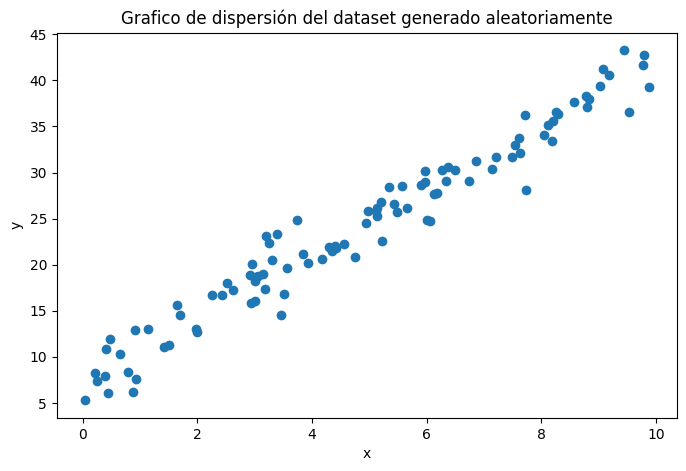

In [3]:
# Graficamos el dataset
plt.figure(figsize=(8,5))
plt.scatter(x_train,y_train)
plt.title("Grafico de dispersión del dataset generado aleatoriamente")
plt.ylabel('y')
plt.xlabel('x')
plt.show()

### Función de costo
El primer paso para desarrollar un algoritmo de regresión lineal es obtener la función de costo, es decir la función que nos va a decir que tan bueno es el modelo creado y que nos permite comparar con otros modelos para poder elegir el mejor.

En Regresion lineal la función de costo suele ser una función cuadrática y está dada por la siguiente ecuación:

${J(w,b)} = \frac{1}{2m}\sum \limits _{i=1} ^{m} (f(x^{(i)}) - y^{(i)})^2$

En donde,

${f(x)} = w*x+b$

#### <font color='red'>**Actividad 1:**</font>

**Desarrollar una función Python que calcule la función de costo cuadrática dado el dataset generado** (valores de x e y) y un modelo dado (es decir, los parámetros w y b son conocidos y pasados por parámetro a la función).

**Nota:**

- x[i]: obtiene el valor del feature x del ejemplo i, es decir, $x^{(i)}$
- y[i]: obtiene el valor del label y del ejemplo i, es decir, $y^{(i)}$
- x**2: calcula el cuadrado de x. Esto será util para calcular $(f(x^{(i)}) - y^{(i)})^2$



In [4]:
def calcular_costo(x, y, w, b):
    """
    Calcula el costo (o error) que presenta un modelo dado en relación a los datos.

    Args:
      x: arreglo con los valores del feature x para cada ejemplo
      y: arreglo con los valores del label y para cada ejemplo
      w,b: parámetros del modelo conocido (numéricos)

    Objetivo:
        La función debe retornar el costo del modelo dado por parámetro
    """
    # Cantidad de ejemplos
    m = x.shape[0]

    cost_sum = 0
    # 1. Por todos los ejemplos, calcular el costo de cada ejemplo:
    for i in range(m):

        # 1.a. Calcular f(x)
        # <<AGREGAR CODIGO>>
        f_x = w * x[i] + b

        # 1.b. Calcular el costo cuadratico
        # <<AGREGAR CODIGO>>
        cost = (f_x - y[i]) ** 2

        # 1.c. Sumar el costo al costo acumulado
        # <<AGREGAR CODIGO>>
        cost_sum += cost

    # 2. Calcular el costo promedio
    # <<AGREGAR CODIGO>>

    # 3. Retornar el costo total del modelo
    return total_cost

### Gradiente Descendente

Ahora que tenemos la función de costo podemos desarrollar el algoritmo de gradiente descendente que la minimice.

Con el algoritmo de gradiente descendente vamos a ir iterativamente buscando modelos y calculando el costo de cada uno de ellos para quedarnos con el modelo que minimice la función de costo, es decir, que presente un error menor que el resto.

Para ello, recordemos que el algoritmo de gradiente descendente consiste en ir buscando valores de w y b y actualizándolos en cada iteración de la siguiente manera:

$\text{repetir hasta convergencia:}$

&emsp;&emsp;&emsp;$w=w-\alpha*\frac{1}{m}\sum \limits _{i=1} ^{m}(f(x^{(i)})-y^{(i)})*x^{(i)}$

&emsp;&emsp;&emsp;$b=b-\alpha*\frac{1}{m}\sum \limits _{i=1} ^{m}(f(x^{(i)})-y^{(i)})$

en donde,

${f(x)} = w*x+b$


#### <font color='red'>**Actividad 2:**</font>

**Desarrollar una función que calcule las derivadas de la funcion de costo con respecto a w y a b**, es decir, una función que devuelva los siguiente calculos:

$\text{Derivada de J(w,b) con respecto a w = }\frac{1}{m}\sum \limits _{i=1} ^{m}(f(x^{(i)})-y^{(i)})*x^{(i)}$

$\text{Derivada de J(w,b) con respecto a b = }\frac{1}{m}\sum \limits _{i=1} ^{m}(f(x^{(i)})-y^{(i)})$

In [5]:
def calcular_derivadas(x, y, w, b):
    """
    Calcula las derivadas de la función de costo con respecto a w y b.
    Args:
      x: arreglo con los valores del feature x para cada ejemplo
      y: arreglo con los valores del label y para cada ejemplo
      w,b: parametros del modelo conocido (numericos)
    Returns
      dj_w: Derivada de la función de costo con respecto a w
      dj_b: Derivada de la función de costo con respecto a b
     """

    # Cantidad de ejemplos
    m = x.shape[0]

    dj_w = 0
    dj_b = 0

    # 1. Por todos los ejemplos, calcular la derivada con respecto a w y a b
    for i in range(m):
        # 1.a. Calcular f(x)
        # <<AGREGAR CODIGO>>
        f_x = w * x[i] + b

        # 1.b. Calcular la derivada con respecto a w para el ejemplo i
        # <<AGREGAR CODIGO>>

        dj_w_i = f_x - y[i]
        # 1.c. Calcular la derivada con respecto a b para el ejemplo i
        # <<AGREGAR CODIGO>>
        dj_b_i = f_x - y[i]


        # 1.d. Sumar la derivada acumulada con respecto a w
        # <<AGREGAR CODIGO>>
        dj_w += dj_w_i
        # 1.e. Sumar la derivada acumulada con respecto a b
        # <<AGREGAR CODIGO>>
        dj_b += dj_b_i

    # 2. Obtener el promedio de las derivadas
    # <<AGREGAR CODIGO>>

    # 3. Retornar las derivadas
    return dj_w, dj_b

Ahora que tenemos una función que calcula las derivadas solo resta actualizar los valores de w y de b simultaneamente, de la siguiente manera:



$\text{repetir hasta convergencia:}$

&emsp;&emsp;&emsp;$w=w-\alpha*\frac{1}{m}\sum \limits _{i=1} ^{m}(f(x^{(i)})-y^{(i)})*x^{(i)}$

&emsp;&emsp;&emsp;$b=b-\alpha*\frac{1}{m}\sum \limits _{i=1} ^{m}(f(x^{(i)})-y^{(i)})$

en donde,

${f(x)} = w*x+b$

#### <font color='red'>**Actividad 3:**</font>

Desarrollar una función que calcule el gradiente descendente, es decir, que actualice los valores de w y de b utilizando la función desarrollada en la actividad anterior.



In [ ]:
def gradiente_descendente(x, y, max_iterations, alpha):
    """
    Calcula el gradiente descendente para encontrar los valores óptimos de w y b.

    Args:
      x: arreglo con los valores del feature x para cada ejemplo
      y: arreglo con los valores del label y para cada ejemplo
      max_iterations: máximo de iteraciones
      alpha: learning rate

    Returns:
      w: valor de w luego de converger
      b: valor de b luego de converger
      J_history (List): valores históricos del costo (para graficar)
      wb_history (list): valores históricos de w y de b (para graficar)
      """

    # Estos arreglos sirven para ir guardando los valores del costo y de los parámetros para graficarlos al final
    J_hist = []
    wb_hist = []

    w = 0
    b = 0

    # Repetir hasta el máximo de iteraciones
    for i in range(max_iterations):

        # 1. Calcular las derivadas
        # <<AGREGAR CODIGO>>

        # 2. Actualizar los valores de w y b
        # <<AGREGAR CODIGO>>

        # 3. Calcular el costo
        # <<AGREGAR CODIGO>>

        # 4. Guardar el costo y los parámetros de la iteración
        J_hist.append(costo)
        wb_hist.append([w,b])

        # Imprime el costo cada 1000 iteraciones
        if i% math.ceil(max_iterations/10) == 0:
            print(f"Iteración {i:4}: Cost {J_hist[-1]:0.2e} ", f"w: {w: 0.3e}, b:{b: 0.5e}")

    # retorna w, b y los arreglos con los costos y parámetros de cada iteración
    return w, b, J_hist, wb_hist

In [ ]:
max_iterations = 10000
alpha = 1.0e-4

w_final, b_final, J_hist, wb_hist = gradiente_descendente(x_train ,y_train, max_iterations, alpha)

print()
print(f"Valores de (w,b) encontrados por el gradiente descendente --> w:{w_final:8.4f}, b:{b_final:8.4f}")

In [ ]:
print(f"Modelo final: " + str(round(w_final,2))+ " * x + " + str(round(b_final,2)))

### Evaluación

En este bloque de código calculamos dos métricas fundamentales para evaluar el rendimiento de nuestro modelo de regresión:

- **MSE (Mean Squared Error)**: mide el error cuadrático medio entre los valores reales y los predichos por el modelo. Un valor más bajo indica un mejor ajuste.  
- **R² (Coeficiente de determinación)**: indica qué proporción de la variabilidad de los datos es explicada por el modelo. Su valor varía entre 0 y 1, siendo 1 un ajuste perfecto.

In [ ]:
y_pred = w_final * x_train + b_final

ss_res = np.sum((y_train - y_pred) ** 2)   # Suma de residuos
ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)  # Suma total de cuadrados
r2 = 1 - (ss_res / ss_tot)

print('MSE: ' + str(J_hist[-1]))
print("R²:", r2)

### Evolución del costo durante el Entrenamiento

Ahora vamor a graficar la evolución de la función de costo a lo largo de las iteraciones del algoritmo de optimización.

- **Eje X**: número de iteración.
- **Eje Y**: valor de la función de costo en esa iteración.

Este gráfico nos permite visualizar cómo el modelo va reduciendo el costo conforme avanza el entrenamiento, lo que indica que los parámetros se ajustan progresivamente para minimizar el error.  


In [ ]:
plt.plot(J_hist[:10000])

plt.title("Costo por iteración")
plt.ylabel('Costo')
plt.xlabel('#iteración')

plt.show()

### Visualización del Modelo Ajustado sobre el Dataset

Veamos gráficamente el ajuste del modelo de regresión lineal sobre los datos de entrenamiento

In [ ]:
# Graficamos el dataset
plt.figure(figsize=(8,5))
plt.scatter(x_train,y_train)

# Definimos el modelo con los parametros encontrados
y_hat = w_final * x_train + b_final

# Graficamos el modelo con una recta roja
plt.plot(x_train, y_hat, color='r')
plt.show()

***

# Práctica 2: Regresión Lineal con Scikit-learn

Ahora que desarrollamos nuestras propias funciones de regresión lineal veamos como podemos implementarlo usando la librería Scikit-Learn.

Comenzamos importando de la librería Scikit-Learn el paquete linear_model que contiene las funciones para hacer Regresión lineal

In [ ]:
from sklearn import linear_model

El dataset que creamos anteriormente lo habiamos aplanado usando el método .flatten() para obtener un arreglo en vez de una matriz, para simplificar el manejo de los datos.

El modelo de regresión lineal de scikit-learn acepta solamente matrices para poder hacer regresión lineal para multiples features.

En nuestro ejemplo sólo tenemos un único feature y por ello con un arreglo era suficiente, pero para usar la librería debemos transformarlo en una matriz nuevamente. Para ello usamos el método .reshape().

In [ ]:
x_train = x_train.reshape(-1, 1)
x_train.shape

Ahora creamos el modelo de regresion lineal usando el metodo LinearRegression()

In [ ]:
regr = linear_model.LinearRegression()

Con el método .fit(x,y) lo que hacemos es ajustar el modelo a los datos.

In [ ]:
regr.fit(x_train, y_train)

Ahora que tenemos el modelo podemos ver los parametros w y b

In [ ]:
print("Parametros: \n w =", regr.coef_, "      b =", regr.intercept_)


Ahora, resta obtener los valores estimados: $\hat{y}$ para poder graficar el modelo

In [ ]:
y_pred = regr.predict(x_train)

# Graficamos el modelo con una recta roja sobre el grafico de dispersión del dataset generado
plt.scatter(x_train, y_train)
plt.plot(x_train, y_pred,color='r')

plt.show()

Vemos que con una pocas líneas de código usando la librería scikit-learn obtenemos un modelo muy similar al conseguido habiendo desarrollado todas las funciones necesarias para desarrollar regresion lineal.


### Evaluación del modelo obtenido con Scikit-Learn

Observamos las métricas MSE y R² de Scikit-Learn

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R² : {r2:.4f}")

***

# Práctica 3: Regresión Lineal Múltiple

Ahora que ya sabemos cómo desarrollar un modelo de Regresión Lineal en pocas líneas de código con Scikit-Learn, avancemos hacia un escenario más realista: **cuando contamos con múltiples variables predictoras (features) en el dataset**.

Para este ejemplo, utilizaremos el dataset California Housing, que contiene información sobre distintas características de viviendas en California y su precio medio.

### 📊 Dataset: California Housing

El dataset **California Housing** de `scikit-learn` proviene del censo de California de 1990.  
Contiene información agregada por zonas geográficas (*block groups*) para predecir el **valor medio de las viviendas** en esa área.

Cada fila representa un bloque geográfico y las columnas son:

| **Feature**       | **Descripción**                                                     | **Unidad** |
|-------------------|---------------------------------------------------------------------|------------|
| **MedInc**        | Ingreso medio de los hogares en el bloque                           | Decenas de miles de USD *(3.5 = $35,000)* |
| **HouseAge**      | Edad mediana de las casas en el bloque                              | Años |
| **AveRooms**      | Promedio de habitaciones por vivienda en el bloque                  | Habitaciones |
| **AveBedrms**     | Promedio de dormitorios por vivienda en el bloque                   | Dormitorios |
| **Population**    | Población total del bloque                                          | Personas |
| **AveOccup**      | Promedio de personas por vivienda                                   | Personas/vivienda |
| **Latitude**      | Latitud geográfica del bloque                                       | Grados |
| **Longitude**     | Longitud geográfica del bloque                                      | Grados |

📌 **Variable objetivo**:
- **MedHouseValue** (*Median House Value*): Precio medio de las viviendas en el bloque, en **cientos de miles de USD** *(2.0 = $200,000)*.

💡 Este dataset combina **variables socioeconómicas** (*MedInc*) y **geográficas** (*Latitude*, *Longitude*), lo que permite explorar patrones espaciales y su relación con el precio de las viviendas.

#### <font color='red'>**Actividad 4:**</font>

Desarrollar un modelo de Regresión Lineal que sea capaz de estimar el precio promedio de las viviendas de un bloque.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

In [ ]:
# <<AGREGAR CODIGO>>

In [ ]:
# Resultados
print("Coeficientes (w):", modelo.coef_)
print("Intercepto (b):", modelo.intercept_)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Gráfico comparando valores reales vs predichos
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Precio real (en cientos de miles)")
plt.ylabel("Precio predicho")
plt.title("Regresión Lineal Múltiple - California Housing")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # línea ideal
plt.show()

In [ ]:
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

- MSE ≈ 0.56 → Como la variable objetivo (MedHouseValue) está en cientos de miles de USD, un MSE de 0.56 significa un RMSE ≈ √0.56 ≈ 0.75, es decir, un error promedio de unos $75,000 por predicción.
- R² ≈ 0.58 → El modelo explica aproximadamente el 58 % de la varianza en el precio de las viviendas.
Para un modelo lineal simple sin ingeniería de features ni interacciones, esto es razonable, pero claramente hay margen de mejora.

📌 **Interpretación:**
- El resultado no es “malo” para un modelo tan básico, pero tampoco es excelente.
- La relación entre features y precio en este dataset no es puramente lineal; hay efectos no lineales y variables que interactúan (ej. la ubicación geográfica con lat/long).

💡 **¿Qué podemos hacer ahora?**
- Podemos tratar de incluir términos polinómicos (PolynomialFeatures) y evaluar si eso ayuda.

***

# Práctica 4: Regresión Polinomial

Para mejorar el modelo lineal que creamos anteriormente, vamos a incorporar features polinómicos y analizar cómo afectan al rendimiento del modelo.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Ingeniería de features - Polinómicas grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [ ]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

In [ ]:
y_pred_poly = model_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

# Resultados
print("Modelo polinomial: MSE = {:.4f}, R² = {:.4f}".format(mse_poly, r2_poly))

📌 Interpretación:
- Si R² = 1 → ajuste perfecto.
- Si R² = 0 → el modelo no mejora nada respecto a predecir siempre la media.
- Si R² < 0 → el modelo es **peor** que predecir siempre la media.

***

# Práctica 5: Regresión Logística para dataset make_moons

En este ejemplo vamos a aplicar Regresión Logística sobre un **dataset sintético en forma de “lunas”** para clasificar **dos clases** no linealmente separables. Entrenaremos el modelo, evaluaremos su rendimiento con un reporte de clasificación y matriz de confusión, y visualizaremos la frontera de decisión que genera.

In [ ]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Crear dataset (dos lunas)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)


In [ ]:
# Graficar
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("Dataset de lunas (make_moons)", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Crear y entrenar el modelo
model = LogisticRegression()
model.fit(X_train, y_train)


In [ ]:
# Predicciones
y_pred = model.predict(X_test)

# Reporte de clasificación
print(classification_report(y_test, y_pred))

In [ ]:
# Visualización de fronteras de decisión
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("Regresión Logística en dataset de lunas")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues)
plt.show()

## Mejorando la Regresión Logística en el dataset make_moons

El modelo de **Regresión Logística** estándar genera fronteras de decisión lineales. En datasets no linealmente separables, como el caso de las dos lunas, esto limita su capacidad de clasificación.  
Una forma de mejorar el desempeño sin abandonar la regresión logística es **transformar las variables de entrada** agregando *features* polinomiales que permitan capturar relaciones no lineales.


### **Variante A – Grado polinomial fijo**
En esta opción se utiliza un `Pipeline` que:
1. Aplica **PolynomialFeatures** de un grado específico (por ejemplo, grado = 3) para generar combinaciones no lineales de las variables originales.
2. Escala las características con `StandardScaler` para mejorar la estabilidad numérica.
3. Entrena una `LogisticRegression` sobre estas nuevas características.

Esta variante es simple y permite definir de antemano el grado polinomial a utilizar.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Datos
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Pipeline: Polinomios -> Escalado -> Logística
pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=500))
])
pipe.fit(X_train, y_train)

print("Accuracy test:", pipe.score(X_test, y_test))

# Visualizar frontera de decisión
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 400),
    np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 400)
)
Z = pipe.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("Logística con features polinomiales (grado=3)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, cmap=plt.cm.Blues)
plt.show()

### **Variante B – Selección automática del grado**
En esta opción se utiliza `GridSearchCV` para:
1. Probar distintos grados polinomiales (1, 2, 3, 4) y valores de regularización `C`.
2. Evaluar el desempeño mediante validación cruzada.
3. Seleccionar la combinación de hiperparámetros que maximiza el rendimiento.

Esta variante es más flexible y ayuda a evitar el sobreajuste, ya que el grado polinomial no se fija de forma arbitraria, sino que se elige en función del desempeño medido.

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = {
    "poly__degree": [1, 2, 3, 4],
    "logreg__C": [0.1, 1.0, 3.0, 10.0]
}

pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=500))
])

gs = GridSearchCV(pipe, grid, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

print("Mejor params:", gs.best_params_)
print("Accuracy val (CV):", gs.best_score_)
print("Accuracy test:", gs.score(X_test, y_test))

# Frontera con el mejor modelo
best = gs.best_estimator_
Z = best.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title(f"Logística con polinomios (best: {gs.best_params_})")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

In [ ]:
# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(gs, X_test, y_test, cmap=plt.cm.Blues)
plt.show()

***

# Bonus Track: Regresión Logística para clasificación de dígitos manuscritos (MNIST)

En esta sección entrenaremos un modelo de **Regresión Logística multinomial** para clasificar dígitos (0–9) del dataset **MNIST**.  

Flujo: **Carga y exploración → Preprocesado → Entrenamiento → Evaluación → Visualización**.

*Objetivo didáctico:* mostrar que un modelo lineal bien configurado es un baseline fuerte y un buen punto de partida antes de pasar a MLP/CNN.

In [ ]:
from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score
import random

### Carga del dataset y visualización

Usamos la versión de MNIST incluida en Keras:
- Imágenes: 28×28 en escala de grises
- Clases: dígitos 0–9

Mostramos una muestra para validar que la carga fue correcta.

In [ ]:
# Cargar MNIST completo
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Opcional: reducir tamaño (por ejemplo, 10.000 para entrenamiento y 2.000 para test)
n_train = 10000
n_test = 2000

X_train = X_train[:n_train]
y_train = y_train[:n_train]
X_test = X_test[:n_test]
y_test = y_test[:n_test]

print(f"Nuevo tamaño -> Train: {X_train.shape}, Test: {X_test.shape}")

# Muestra rápida de imágenes
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for ax in axes.ravel():
    i = random.randrange(len(X_train))
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(str(y_train[i]), fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

### Preprocesado

- Aplanamos cada imagen de 28×28 → vector de 784 features.
- Convertimos a `float32`.
- Unimos train+test y volvemos a separar con `train_test_split` para tener un **conjunto de validación** más controlado.

In [ ]:
# Unir y rearmar splits (opcional pero útil para control)
X = np.concatenate([X_train, X_test], axis=0).astype("float32")
y = np.concatenate([y_train, y_test], axis=0)

# (n_samples, 28, 28) -> (n_samples, 784)
X = X.reshape(len(X), -1)

# Train/Test (p.ej. 60k/10k)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

X_tr.shape, X_te.shape

### Pipeline: Estandarización + Regresión Logística Multinomial

- `StandardScaler(with_mean=False)`: evita centrado (más estable en datos dispersos/altas dimensiones).
- `LogisticRegression(multi_class="multinomial", solver="saga")`: eficiente para muchas muestras y soporta regularización L2.
- Ajustamos `max_iter` para asegurar convergencia.

In [ ]:
clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        solver="saga",
        C=1.0,
        max_iter=200,   # subir a 300–500 si avisa no convergencia
        n_jobs=-1,
        verbose=0
    ))
])

clf.fit(X_tr, y_tr)

### Evaluación

Calculamos **accuracy**, mostramos un **reporte de clasificación** y la **matriz de confusión**.  
Esto nos da una visión global del desempeño y de dónde se confunde el modelo.

In [ ]:
y_pred = clf.predict(X_te)
acc = accuracy_score(y_te, y_pred)
print(f"Accuracy en test: {acc:.4f}\n")

print(classification_report(y_te, y_pred, digits=4))

disp = ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred, display_labels=list(range(10)), xticks_rotation=0, cmap=None
)
disp.ax_.set_title("Matriz de confusión – Regresión Logística (MNIST)")
plt.tight_layout(); plt.show()

### Visualización de ejemplos bien y mal clasificados

Visualizamos algunas predicciones correctas y otras incorrectas para entender patrones de error.

In [ ]:
def plot_examples(Xv, y_true, y_hat, title, mask, k=12):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        print("No hay ejemplos para mostrar:", title)
        return
    sel = np.random.choice(idx, size=min(k, len(idx)), replace=False)
    ncols = 6
    nrows = int(np.ceil(len(sel)/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 1.8*nrows))
    axes = np.array(axes).reshape(-1)
    for ax, i in zip(axes, sel):
        ax.imshow(Xv[i].reshape(28,28), cmap="gray")
        ax.set_title(f"gt:{y_true[i]} pred:{y_hat[i]}", fontsize=9)
        ax.axis("off")
    for ax in axes[len(sel):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_examples(X_te, y_te, y_pred, "Bien clasificados", y_pred == y_te)
plot_examples(X_te, y_te, y_pred, "Mal clasificados", y_pred != y_te)